In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

0.00016028108553923622 1.3330999169005471e-06 2.5763048228567153e-05 3.4582521118442693e-07 0.00011429844958543477 2.3091596757207325e-06


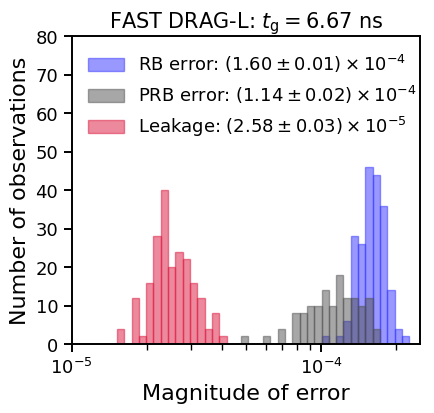

In [2]:
#Re-read csv-files and plot
dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 
light_red = [240/255,128/255,128/255]
dark_gray = [80/255, 80/255, 80/255] #[64/255, 64/255, 64/255]
colors_list = [dark_blue, dark_gray, crimson]        


gate_error_list = np.genfromtxt('gate_error_list.csv', delimiter=',')
incoherent_error_list = np.genfromtxt('incoherent_error_list.csv', delimiter=',')
leakage_error_list = np.genfromtxt('leakage_error_list.csv', delimiter=',')
mean_gate_error = np.mean(gate_error_list)
uncertainty_gate_error = np.std(gate_error_list) / np.sqrt(len(gate_error_list))
mean_leakage_error = np.mean(leakage_error_list)
uncertainty_leakage_error = np.std(leakage_error_list) / np.sqrt(len(leakage_error_list))
mean_incoherent_error = np.mean(incoherent_error_list)
uncertainty_incoherent_error = np.std(incoherent_error_list) / np.sqrt(len(incoherent_error_list))
print(mean_gate_error, uncertainty_gate_error, mean_leakage_error, uncertainty_leakage_error, mean_incoherent_error, uncertainty_incoherent_error)


fig, ax = plt.subplots(1, 1, figsize=(4.5,4))
bin_min = np.nanmin([np.nanmin(leakage_error_list), np.nanmin(gate_error_list), np.nanmin(incoherent_error_list)])*0.9
bin_max = np.nanmax([np.nanmax(leakage_error_list), np.nanmax(gate_error_list), np.nanmax(incoherent_error_list)])*1.1
n_bins = 42
bins = np.logspace(np.log10(bin_min), np.log10(bin_max), n_bins + 1)

plt.hist(gate_error_list, bins = bins, color=colors_list[0], edgecolor=colors_list[0], alpha = 0.5, label=r'RB error: $(%.2f\pm %.2f)\times 10^{-4}$'%(mean_gate_error*1e4, uncertainty_gate_error*1e4))
plt.hist(incoherent_error_list, bins = bins, color=colors_list[1],  edgecolor=colors_list[1], alpha = 0.5, label=r'PRB error: $(%.2f\pm %.2f)\times 10^{-4}$'%(mean_incoherent_error*1e4, uncertainty_incoherent_error*1e4))
plt.hist(leakage_error_list, bins = bins, color=colors_list[2], alpha = 0.5, edgecolor=colors_list[2], label=r'Leakage: $(%.2f\pm %.2f)\times 10^{-5}$'%(mean_leakage_error*1e5, uncertainty_leakage_error*1e5))

plt.xlabel(r'Magnitude of error', fontsize = 16)
plt.ylabel(r'Number of observations', fontsize = 16)
plt.title(r'FAST DRAG-L: $t_\mathrm{g}=6.67$ ns',  fontsize = 15)
ax.legend(fontsize=13, loc='upper left', frameon=False)
plt.xlim([1e-5, 2.5e-4])
plt.ylim([0, 80])
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
ax.tick_params(length=6, width = 1.4)
ax.tick_params('both', length=4, width=1, which='minor')
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
ax.set_xscale("log")
